# Infografis 1 — Ketimpangan Ekonomi Antar Wilayah Jawa Timur
Notebook ini analisis pendukung untuk **Infografis 1**, melengkapi dashboard monitoring pembangunan Jawa Timur (PKL Kominfo).

**Data yang dipakai:**
- Data existing dari dashboard: `master_dashboard_final.csv` (kemiskinan, IPM, TPT, kepadatan, jumlah penduduk per kab/kota per tahun)
- Data tambahan: PDRB per kapita per kab/kota (BPS Jatim) — kamu download & taruh di folder `data/` di sini

**3 analisis di notebook ini:**
1. Williamson Index & Coefficient of Variation (CV) — tren ketimpangan ekonomi antar wilayah dari tahun ke tahun
2. Korelasi Pearson — hubungan PDRB per kapita dengan kemiskinan
3. Klasterisasi K-Means — mengelompokkan 38 kab/kota jadi 3 klaster berdasarkan profil ekonomi-sosial

Struktur folder yang disarankan (di luar folder dashboard, sesuai request kamu):
```
infografis-1-ketimpangan-ekonomi/
├── data/
│   └── pdrb_per_kapita_jatim.csv      <- taruh hasil download BPS di sini
├── output/                             <- hasil olahan notebook ini disimpan di sini
└── analisis_ketimpangan_ekonomi.ipynb  <- file ini
```


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Load Data

Sesuaikan `MASTER_PATH` sesuai lokasi folder dashboard kamu relatif terhadap folder notebook ini.
Kalau folder notebook ini sejajar (sibling) dengan folder repo dashboard, path `../` di bawah biasanya sudah benar — tinggal ganti nama folder repo-nya kalau beda.


In [64]:
import os

print("CURRENT WORKING DIRECTORY:")
print(os.getcwd())

print("\nISI FOLDER SAAT INI:")
print(os.listdir("."))

print("\nISI FOLDER SATU LEVEL DI ATAS:")
print(os.listdir(".."))

CURRENT WORKING DIRECTORY:
c:\Users\Hp Victus\Downloads\PKL-KOMINFO-NEW\analisis_infografis\infografis_1_ketimpangan_ekonomi

ISI FOLDER SAAT INI:
['analisis_ketimpangan_ekonomi.ipynb', 'output']

ISI FOLDER SATU LEVEL DI ATAS:
['data', 'infografis_1_ketimpangan_ekonomi']


In [65]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if "pdrb" in file.lower():
            print(os.path.join(root, file))

..\data\pdrb_per_kapita_ 2019.csv
..\data\pdrb_per_kapita_2018.csv
..\data\pdrb_per_kapita_2020.csv
..\data\pdrb_per_kapita_2021.csv
..\data\pdrb_per_kapita_2022.csv
..\data\pdrb_per_kapita_2023.csv
..\data\pdrb_per_kapita_2024.csv
..\data\pdrb_per_kapita_2025.csv
..\infografis_1_ketimpangan_ekonomi\output\korelasi_pdrb_kemiskinan.png


In [66]:
import pandas as pd
from pathlib import Path

# =========================
# PATH DATA
# =========================

MASTER_PATH = "../../output/master_dashboard_final.csv"
DATA_DIR = Path("../data")

# =========================
# LOAD MASTER
# =========================

df_master = pd.read_csv(MASTER_PATH)

print("master_dashboard_final:", df_master.shape)
display(df_master.head())


# =========================
# LOAD SEMUA DATA PDRB 2018-2025
# =========================

pdrb_files = sorted(DATA_DIR.glob("pdrb_per_kapita_*.csv"))

print("File PDRB yang ditemukan:")
for file in pdrb_files:
    print("-", file)


# Baca semua file
df_pdrb_list = []

for file in pdrb_files:

    df_temp = pd.read_csv(file)

    # Ambil tahun dari nama file
    tahun = int(file.stem.split("_")[-1])

    # Tambahkan kolom tahun
    df_temp["tahun"] = tahun

    df_pdrb_list.append(df_temp)


# =========================
# GABUNGKAN SEMUA TAHUN
# =========================

df_pdrb = pd.concat(
    df_pdrb_list,
    ignore_index=True
)

print("\nData PDRB setelah digabung:", df_pdrb.shape)

display(df_pdrb.head())

master_dashboard_final: (304, 15)


,kode_wilayah,nama_wilayah,tipe_wilayah,jumlah_penduduk,laju_pertumbuhan,persentase_penduduk,kepadatan_bps,rasio_jenis_kelamin,tahun,jumlah_penduduk_miskin,tpt,ipm,kepadatan_sipil_smt1,kepadatan_sipil_smt2,kepadatan_sipil_tahunan
0,3501,Pacitan,Kabupaten,554.00,0.31,1.06,399.00,95.40,2018,78.64,1.39,67.33,425.29,426.60,425.95
1,3501,Pacitan,Kabupaten,555.00,0.29,1.40,400.00,95.40,2019,75.86,0.91,68.16,427.91,429.19,428.55
2,3501,Pacitan,Kabupaten,586.10,0.78,1.44,422.00,100.50,2020,80.82,2.28,68.39,429.75,525.19,477.47
3,3501,Pacitan,Kabupaten,589.10,0.68,1.44,424.00,100.40,2021,84.19,2.04,69.45,429.94,430.24,430.09
4,3501,Pacitan,Kabupaten,592.90,0.66,1.44,414.00,100.40,2022,76.93,3.65,70.59,418.00,417.96,417.98


File PDRB yang ditemukan:
- ..\data\pdrb_per_kapita_ 2019.csv
- ..\data\pdrb_per_kapita_2018.csv
- ..\data\pdrb_per_kapita_2020.csv
- ..\data\pdrb_per_kapita_2021.csv
- ..\data\pdrb_per_kapita_2022.csv
- ..\data\pdrb_per_kapita_2023.csv
- ..\data\pdrb_per_kapita_2024.csv
- ..\data\pdrb_per_kapita_2025.csv

Data PDRB setelah digabung: (326, 3)


,Kabupaten/Kota,Per Capita Gross Regional Domestic Product at Current Market Prices (Thousand Rp),tahun
0,Pacitan,"28,734.00",2019
1,Ponorogo,"23,423.00",2019
2,Trenggalek,"26,634.00",2019
3,Tulungagung,"37,725.00",2019
4,Blitar,"31,388.00",2019


## 2. Cleaning & Join

Nama wilayah di data BPS biasanya masih pakai prefix "Kabupaten"/"Kota" (misal "Kabupaten Pacitan"), sedangkan `nama_wilayah` di data dashboard kamu kemungkinan sudah bersih (misal "Pacitan"). Sel di bawah membersihkan itu supaya join-nya nyambung.

**Pastikan kolom di `df_pdrb` minimal punya:** `nama_wilayah`, `tahun`, `pdrb_per_kapita` — sesuaikan nama kolomnya kalau beda pas kamu download.


In [67]:
# =========================
# SESUAIKAN KOLOM PDRB
# =========================

df_pdrb = df_pdrb.rename(columns={
    "Kabupaten/Kota": "nama_wilayah",
    "Per Capita Gross Regional Domestic Product at Current Market Prices (Thousand Rp)": "pdrb_per_kapita"
})


# =========================
# CLEANING NILAI PDRB
# =========================

# Jadikan string terlebih dahulu
df_pdrb["pdrb_per_kapita"] = (
    df_pdrb["pdrb_per_kapita"]
    .astype(str)
    .str.strip()
)

# Hapus catatan BPS seperti:
# (*)*
# (*)
# (**)
# (**)**
# dan tanda bintang lainnya
df_pdrb["pdrb_per_kapita"] = (
    df_pdrb["pdrb_per_kapita"]
    .str.replace(r"\(.*?\)", "", regex=True)
    .str.replace("*", "", regex=False)
    .str.strip()
)

# Ubah menjadi numerik
df_pdrb["pdrb_per_kapita"] = pd.to_numeric(
    df_pdrb["pdrb_per_kapita"],
    errors="coerce"
)


# =========================
# PASTIKAN TAHUN NUMERIK
# =========================

df_pdrb["tahun"] = pd.to_numeric(
    df_pdrb["tahun"],
    errors="coerce"
).astype("Int64")


# =========================
# CEK HASIL
# =========================

print("\nKolom PDRB setelah disesuaikan:")
print(df_pdrb.columns.tolist())

print("\nTipe data:")
print(df_pdrb.dtypes)

print("\nJumlah PDRB per tahun:")

cek_pdrb = (
    df_pdrb.groupby("tahun")["pdrb_per_kapita"]
    .agg(
        jumlah_data="count",
        jumlah_missing=lambda x: x.isna().sum()
    )
)

display(cek_pdrb)


# =========================
# CEK CONTOH 2024 & 2025
# =========================

print("\n=== CONTOH PDRB 2024 ===")

display(
    df_pdrb[
        df_pdrb["tahun"] == 2024
    ].head(10)
)


print("\n=== CONTOH PDRB 2025 ===")

display(
    df_pdrb[
        df_pdrb["tahun"] == 2025
    ].head(10)
)


Kolom PDRB setelah disesuaikan:
['nama_wilayah', 'pdrb_per_kapita', 'tahun']

Tipe data:
nama_wilayah           str
pdrb_per_kapita    float64
tahun                Int64
dtype: object

Jumlah PDRB per tahun:


,jumlah_data,jumlah_missing
tahun,,
2018,38,4
2019,38,4
2020,38,0
2021,38,0
2022,38,0
2023,38,4
2024,38,5
2025,38,5



=== CONTOH PDRB 2024 ===


,nama_wilayah,pdrb_per_kapita,tahun
240,Pacitan,"35,096.00",2024
241,Ponorogo,"28,088.00",2024
242,Trenggalek,"32,726.00",2024
243,Tulungagung,"46,009.00",2024
244,Blitar,"37,811.00",2024
245,Kediri,"32,339.00",2024
246,Malang,"50,593.00",2024
247,Lumajang,"37,579.00",2024
248,Jember,"39,464.00",2024
249,Banyuwangi,"62,086.00",2024



=== CONTOH PDRB 2025 ===


,nama_wilayah,pdrb_per_kapita,tahun
283,Pacitan,"38,215.00",2025
284,Ponorogo,"30,007.00",2025
285,Trenggalek,"35,110.00",2025
286,Tulungagung,"49,485.00",2025
287,Blitar,"40,200.00",2025
288,Kediri,"34,496.00",2025
289,Malang,"54,521.00",2025
290,Lumajang,"40,349.00",2025
291,Jember,"42,357.00",2025
292,Banyuwangi,"67,081.00",2025


In [68]:
# Cek semua baris yang PDRB-nya NaN
pdrb_missing = df_pdrb[
    df_pdrb["pdrb_per_kapita"].isna()
]

display(
    pdrb_missing[
        ["nama_wilayah", "pdrb_per_kapita", "tahun"]
    ]
)

,nama_wilayah,pdrb_per_kapita,tahun
38,NaN,NaN,2019
39,Keterangan,NaN,2019
40,Perbedaan antara jumlah PDRB 34 Provinsi dan P...,NaN,2019
41,The difference between the total of GRDP of 34...,NaN,2019
80,NaN,NaN,2018
81,Keterangan,NaN,2018
82,Perbedaan antara jumlah PDRB 34 Provinsi dan P...,NaN,2018
83,The difference between the total of GRDP of 34...,NaN,2018
236,NaN,NaN,2023
237,Keterangan,NaN,2023


In [69]:
#membersihkan kolom missing
# =========================
# CLEANING DATA PDRB
# =========================

# Ubah nilai PDRB menjadi numerik
# Nilai yang bukan angka akan menjadi NaN
df_pdrb["pdrb_per_kapita"] = pd.to_numeric(
    df_pdrb["pdrb_per_kapita"],
    errors="coerce"
)

# Hapus baris yang bukan wilayah/kabupaten/kota
# yaitu baris yang tidak memiliki nilai PDRB
df_pdrb = df_pdrb.dropna(
    subset=["nama_wilayah", "pdrb_per_kapita"]
).copy()

# Rapikan nama wilayah
df_pdrb["nama_wilayah"] = (
    df_pdrb["nama_wilayah"]
    .astype(str)
    .str.strip()
)

print("Jumlah data setelah cleaning:", len(df_pdrb))
print("Jumlah wilayah unik:", df_pdrb["nama_wilayah"].nunique())

print("\nJumlah wilayah per tahun:")
print(
    df_pdrb.groupby("tahun")["nama_wilayah"]
    .nunique()
)

print("\nJumlah data per tahun:")
print(
    df_pdrb.groupby("tahun").size()
)

display(df_pdrb.tail())

Jumlah data setelah cleaning: 304
Jumlah wilayah unik: 38

Jumlah wilayah per tahun:
tahun
2018    38
2019    38
2020    38
2021    38
2022    38
2023    38
2024    38
2025    38
Name: nama_wilayah, dtype: int64

Jumlah data per tahun:
tahun
2018    38
2019    38
2020    38
2021    38
2022    38
2023    38
2024    38
2025    38
dtype: int64


,nama_wilayah,pdrb_per_kapita,tahun
316,Kota Pasuruan,"54,006.00",2025
317,Kota Mojokerto,"66,235.00",2025
318,Kota Madiun,"98,078.00",2025
319,Kota Surabaya,"283,306.00",2025
320,Kota Batu,"105,197.00",2025


In [70]:
def bersihkan_nama_wilayah(nama):
    nama = str(nama).strip()
    # HANYA strip prefix "Kabupaten " — prefix "Kota " HARUS tetap dipertahankan,
    # karena itu yang membedakan Kota Blitar dari Kabupaten Blitar, dst.
    if nama.startswith("Kabupaten "):
        nama = nama.replace("Kabupaten ", "", 1)
    return nama.strip()

# df_master TIDAK perlu dibersihkan lagi — nama_wilayah di sana sudah
# mengikuti konvensi ini dari sananya (Kabupaten = polos, Kota = "Kota X")
df_pdrb["nama_wilayah"] = df_pdrb["nama_wilayah"].apply(bersihkan_nama_wilayah)

df = df_master.merge(df_pdrb[["nama_wilayah", "tahun", "pdrb_per_kapita"]],
                      on=["nama_wilayah", "tahun"], how="inner")

# Cek wilayah yang gagal ke-join (harusnya kosong / minim)
wilayah_gagal = set(df_master["nama_wilayah"]) - set(df["nama_wilayah"])
print("Wilayah yang tidak ter-join (cek ejaan namanya kalau ada):", wilayah_gagal)

print("Hasil join:", df.shape)
display(df.head())


Wilayah yang tidak ter-join (cek ejaan namanya kalau ada): set()
Hasil join: (304, 16)


,kode_wilayah,nama_wilayah,tipe_wilayah,jumlah_penduduk,laju_pertumbuhan,persentase_penduduk,kepadatan_bps,rasio_jenis_kelamin,tahun,jumlah_penduduk_miskin,tpt,ipm,kepadatan_sipil_smt1,kepadatan_sipil_smt2,kepadatan_sipil_tahunan,pdrb_per_kapita
0,3501,Pacitan,Kabupaten,554.00,0.31,1.06,399.00,95.40,2018,78.64,1.39,67.33,425.29,426.60,425.95,"27,000.00"
1,3501,Pacitan,Kabupaten,555.00,0.29,1.40,400.00,95.40,2019,75.86,0.91,68.16,427.91,429.19,428.55,"28,734.00"
2,3501,Pacitan,Kabupaten,586.10,0.78,1.44,422.00,100.50,2020,80.82,2.28,68.39,429.75,525.19,477.47,"26,972.00"
3,3501,Pacitan,Kabupaten,589.10,0.68,1.44,424.00,100.40,2021,84.19,2.04,69.45,429.94,430.24,430.09,"27,932.00"
4,3501,Pacitan,Kabupaten,592.90,0.66,1.44,414.00,100.40,2022,76.93,3.65,70.59,418.00,417.96,417.98,"30,627.00"


## 3. Analisis 1 — Williamson Index & Coefficient of Variation (Tren Ketimpangan)

Rasio "PDRB tertinggi ÷ terendah" gampang dimengerti tapi rentan bias outlier. Dua ukuran di bawah lebih standar dipakai di literatur ekonomi regional:

- **CV (Coefficient of Variation)** = simpangan baku PDRB per kapita ÷ rata-rata PDRB per kapita, dihitung per tahun. Semakin besar CV, semakin timpang.
- **Williamson Index (Vw)** = seperti CV tapi *dibobot jumlah penduduk* tiap wilayah, jadi daerah yang penduduknya besar punya pengaruh lebih besar terhadap angka ketimpangan (lebih representatif secara ekonomi).

Karena data kamu multi-tahun (2018-2025), kita hitung index ini **per tahun** lalu plot jadi tren — ini yang bikin analisis kamu lebih kuat daripada snapshot 1 tahun.


In [71]:
#----memperbaiki tipe data-----
# Pastikan variabel numerik
df["pdrb_per_kapita"] = pd.to_numeric(
    df["pdrb_per_kapita"],
    errors="coerce"
)

df["jumlah_penduduk"] = pd.to_numeric(
    df["jumlah_penduduk"],
    errors="coerce"
)

df["tahun"] = pd.to_numeric(
    df["tahun"],
    errors="coerce"
)

print(df[[
    "pdrb_per_kapita",
    "jumlah_penduduk",
    "tahun"
]].dtypes)

pdrb_per_kapita    float64
jumlah_penduduk    float64
tahun                int64
dtype: object


In [72]:
print(df["pdrb_per_kapita"].isna().sum())
print(df["pdrb_per_kapita"].head(20))

0
0    27,000.00
1    28,734.00
2    26,972.00
3    27,932.00
4    30,627.00
5    33,149.00
6    35,096.00
7    38,215.00
8    22,021.00
9    23,423.00
10   21,654.00
11   22,432.00
12   24,094.00
13   26,314.00
14   28,088.00
15   30,007.00
16   24,974.00
17   26,634.00
18   25,087.00
19   26,160.00
Name: pdrb_per_kapita, dtype: float64


In [73]:
# Lihat baris yang PDRB-nya tidak ditemukan
missing_pdrb = df[df["pdrb_per_kapita"].isna()].copy()

print("Jumlah baris PDRB missing:", len(missing_pdrb))

display(
    missing_pdrb[
        ["nama_wilayah", "tahun"]
    ].sort_values(["tahun", "nama_wilayah"])
)

Jumlah baris PDRB missing: 0


,nama_wilayah,tahun


In [74]:
import pandas as pd

MASTER_PATH = "../../output/master_dashboard_final.csv"

df_check = pd.read_csv(MASTER_PATH)

# 1. Jumlah baris per tahun
print("=== JUMLAH BARIS PER TAHUN ===")
print(df_check.groupby("tahun").size())

# 2. Jumlah wilayah unik per tahun
print("\n=== JUMLAH WILAYAH UNIK PER TAHUN ===")
print(
    df_check.groupby("tahun")["nama_wilayah"]
    .nunique()
)

# 3. Jumlah seluruh wilayah unik
print("\n=== TOTAL WILAYAH UNIK ===")
print(df_check["nama_wilayah"].nunique())

# 4. Daftar wilayah
print("\n=== DAFTAR WILAYAH ===")
print(
    sorted(df_check["nama_wilayah"].dropna().unique())
)

=== JUMLAH BARIS PER TAHUN ===
tahun
2018    38
2019    38
2020    38
2021    38
2022    38
2023    38
2024    38
2025    38
dtype: int64

=== JUMLAH WILAYAH UNIK PER TAHUN ===
tahun
2018    38
2019    38
2020    38
2021    38
2022    38
2023    38
2024    38
2025    38
Name: nama_wilayah, dtype: int64

=== TOTAL WILAYAH UNIK ===
38

=== DAFTAR WILAYAH ===
['Bangkalan', 'Banyuwangi', 'Blitar', 'Bojonegoro', 'Bondowoso', 'Gresik', 'Jember', 'Jombang', 'Kediri', 'Kota Batu', 'Kota Blitar', 'Kota Kediri', 'Kota Madiun', 'Kota Malang', 'Kota Mojokerto', 'Kota Pasuruan', 'Kota Probolinggo', 'Kota Surabaya', 'Lamongan', 'Lumajang', 'Madiun', 'Magetan', 'Malang', 'Mojokerto', 'Nganjuk', 'Ngawi', 'Pacitan', 'Pamekasan', 'Pasuruan', 'Ponorogo', 'Probolinggo', 'Sampang', 'Sidoarjo', 'Situbondo', 'Sumenep', 'Trenggalek', 'Tuban', 'Tulungagung']


In [75]:
print(
    df_master.groupby("tahun").size()
)

tahun
2018    38
2019    38
2020    38
2021    38
2022    38
2023    38
2024    38
2025    38
dtype: int64


,tahun,cv,williamson_index
0,2018,1.28,0.98
1,2019,1.29,0.99
2,2020,1.30,1.00
3,2021,1.30,1.00
4,2022,1.28,1.00
5,2023,1.25,0.99
6,2024,1.24,0.99
7,2025,1.21,0.98


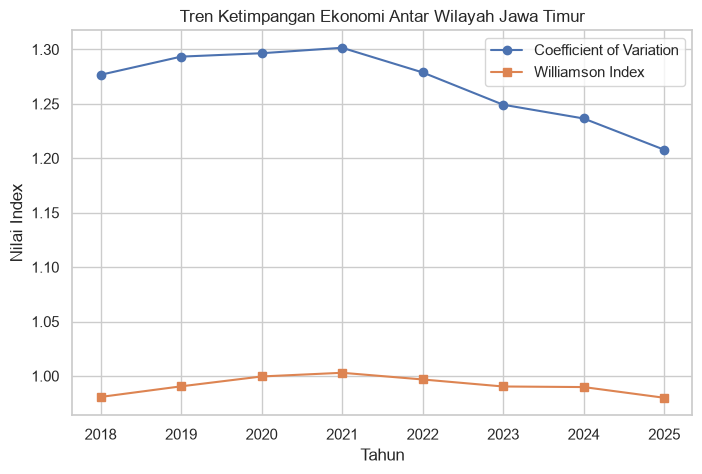

In [76]:
def hitung_index_ketimpangan(group):
    y = group["pdrb_per_kapita"].values
    pop = group["jumlah_penduduk"].values

    # CV sederhana (tidak dibobot)
    cv = np.std(y, ddof=0) / np.mean(y)

    # Williamson Index (dibobot jumlah penduduk)
    f = pop / pop.sum()                          # pangsa penduduk tiap wilayah
    y_bar_w = np.sum(f * y)                       # rata-rata PDRB per kapita, dibobot penduduk
    vw = np.sqrt(np.sum(f * (y - y_bar_w) ** 2)) / y_bar_w

    return pd.Series({"cv": cv, "williamson_index": vw})

df_index = df.groupby("tahun").apply(hitung_index_ketimpangan).reset_index()
display(df_index)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_index["tahun"], df_index["cv"], marker="o", label="Coefficient of Variation")
ax.plot(df_index["tahun"], df_index["williamson_index"], marker="s", label="Williamson Index")
ax.set_title("Tren Ketimpangan Ekonomi Antar Wilayah Jawa Timur")
ax.set_xlabel("Tahun")
ax.set_ylabel("Nilai Index")
ax.legend()
import os

os.makedirs("output", exist_ok=True)

plt.savefig(
    "output/tren_ketimpangan.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


**Cara baca hasilnya:** kalau garis makin naik dari tahun ke tahun, artinya kesenjangan ekonomi antar kab/kota di Jatim makin melebar meski PDRB provinsi tumbuh. Kalau menurun, ketimpangan mengecil. Ini jadi salah satu headline finding infografis kamu.


## 4. Analisis 2 — Korelasi Pearson: PDRB per Kapita vs Kemiskinan

Kita hitung koefisien korelasi Pearson (r) beneran, bukan cuma "kelihatannya begini" dari scatter plot. Pakai data tahun terbaru yang tersedia di kedua dataset.


Tahun: 2025
Koefisien korelasi Pearson (r) = -0.255
P-value = 0.1216  (tidak signifikan pada alpha=0.05)


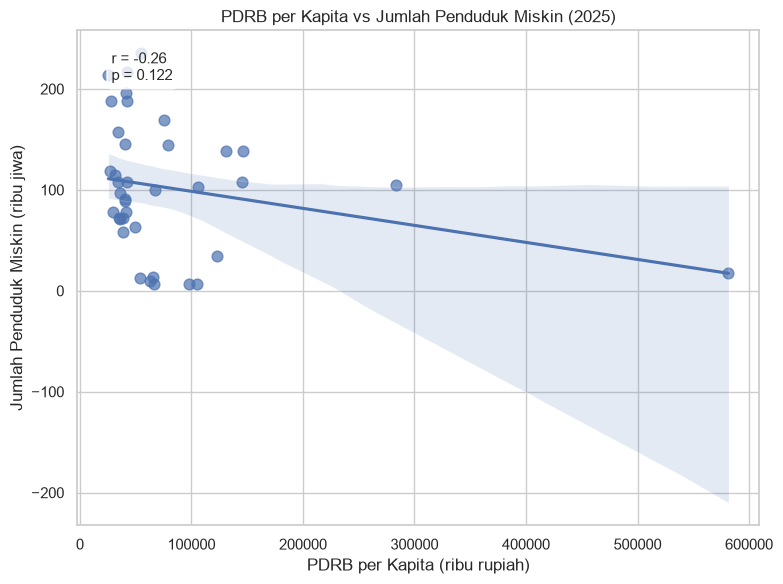


Bonus — Korelasi PDRB per Kapita vs TPT: r = 0.240, p = 0.1459


In [ ]:
tahun_terbaru = df["tahun"].max()
df_latest = df[df["tahun"] == tahun_terbaru].dropna(subset=["pdrb_per_kapita", "jumlah_penduduk_miskin"])

r, p_value = pearsonr(df_latest["pdrb_per_kapita"], df_latest["jumlah_penduduk_miskin"])
print(f"Tahun: {tahun_terbaru}")
print(f"Koefisien korelasi Pearson (r) = {r:.3f}")
print(f"P-value = {p_value:.4f}  ({'signifikan' if p_value < 0.05 else 'tidak signifikan'} pada alpha=0.05)")

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=df_latest, x="pdrb_per_kapita", y="jumlah_penduduk_miskin", ax=ax,
            scatter_kws={"s": 60, "alpha": 0.7})
ax.set_title(f"PDRB per Kapita vs Jumlah Penduduk Miskin ({tahun_terbaru})")
ax.set_xlabel("PDRB per Kapita (ribu rupiah)")
ax.set_ylabel("Jumlah Penduduk Miskin (ribu jiwa)")
ax.annotate(f"r = {r:.2f}\np = {p_value:.3f}", xy=(0.05, 0.9), xycoords="axes fraction",
            fontsize=11, bbox=dict(boxstyle="round", fc="white", alpha=0.8))
plt.tight_layout()
plt.savefig("output/korelasi_pdrb_kemiskinan.png", dpi=200)
plt.show()

# Bonus: cek juga korelasinya dengan TPT, biar makin lengkap kalau perlu
r_tpt, p_tpt = pearsonr(df_latest["pdrb_per_kapita"], df_latest["tpt"])
print(f"\nBonus — Korelasi PDRB per Kapita vs TPT: r = {r_tpt:.3f}, p = {p_tpt:.4f}")


Tahun               : 2025
Jumlah wilayah      : 38
Korelasi Pearson (r): -0.255
P-value             : 0.1216
Kesimpulan          : TIDAK SIGNIFIKAN


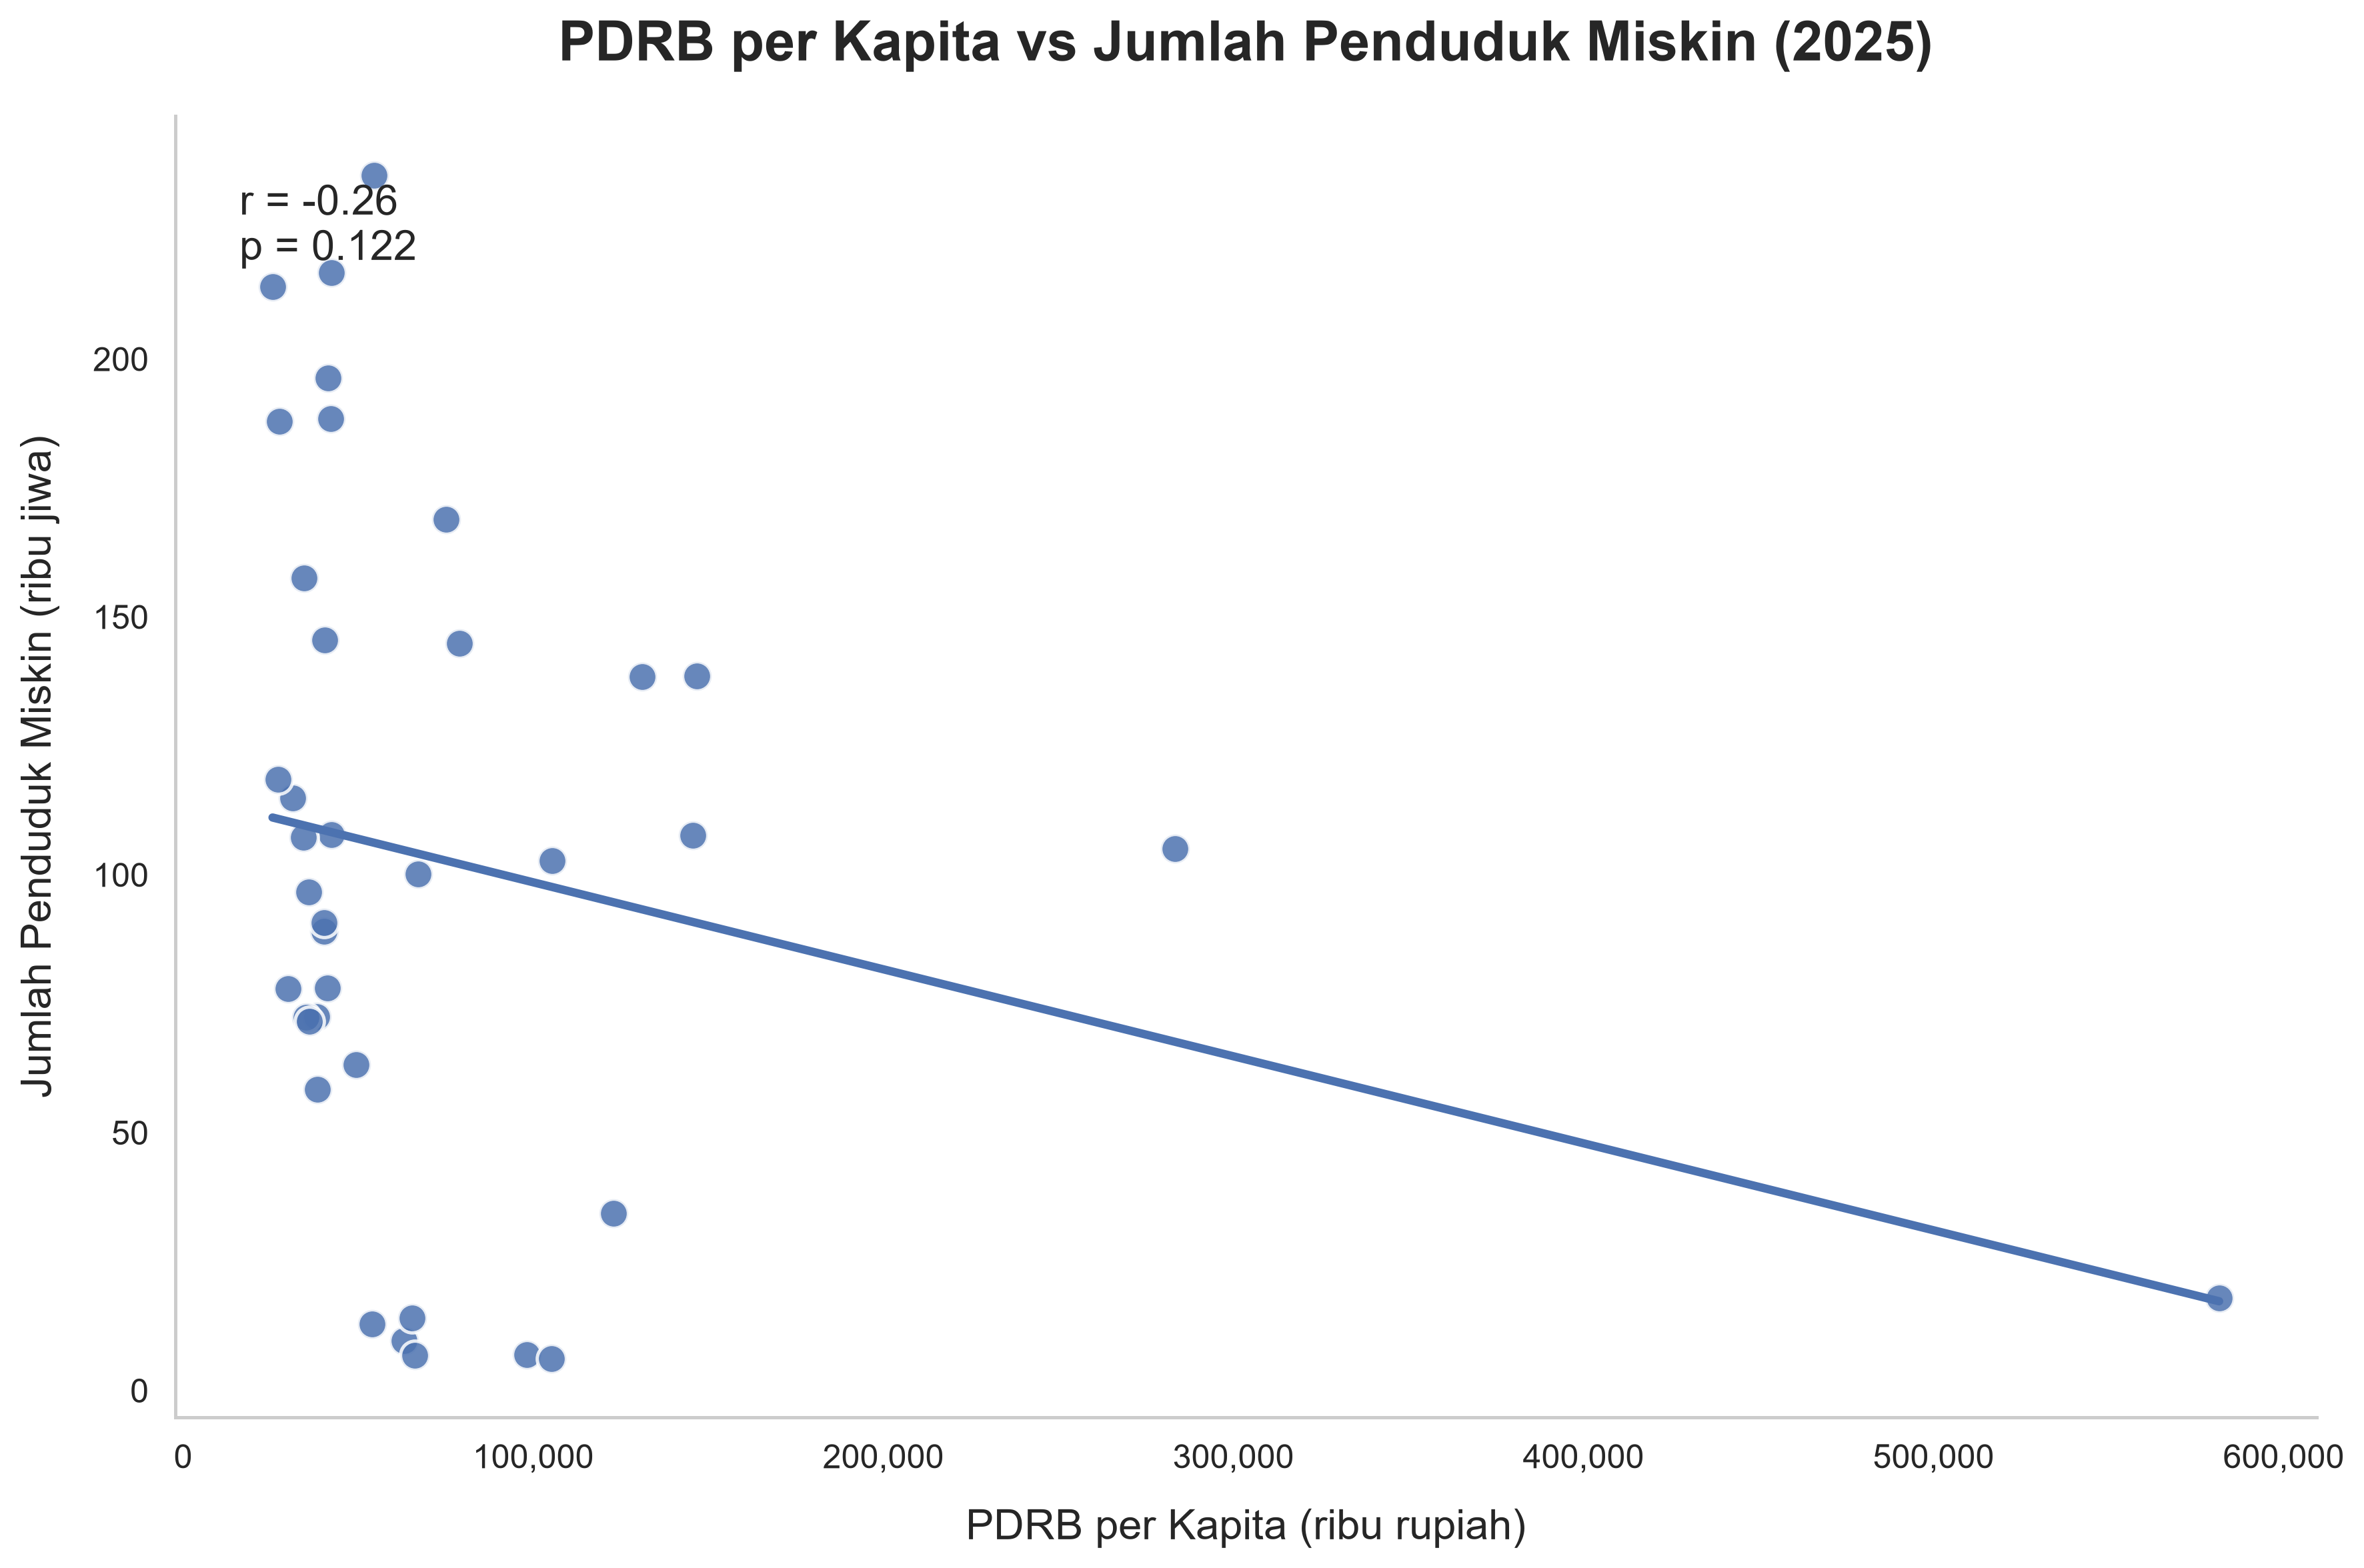

In [85]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.ticker import FuncFormatter

# ============================================================
# 1. AMBIL DATA TAHUN TERBARU
# ============================================================

tahun_terbaru = df["tahun"].max()

df_latest = df[
    df["tahun"] == tahun_terbaru
].dropna(
    subset=["pdrb_per_kapita", "jumlah_penduduk_miskin"]
).copy()

# Pastikan numerik
df_latest["pdrb_per_kapita"] = pd.to_numeric(
    df_latest["pdrb_per_kapita"],
    errors="coerce"
)

df_latest["jumlah_penduduk_miskin"] = pd.to_numeric(
    df_latest["jumlah_penduduk_miskin"],
    errors="coerce"
)

# Hapus NaN setelah konversi
df_latest = df_latest.dropna(
    subset=["pdrb_per_kapita", "jumlah_penduduk_miskin"]
)


# ============================================================
# 2. KORELASI PEARSON
# ============================================================

r, p_value = pearsonr(
    df_latest["pdrb_per_kapita"],
    df_latest["jumlah_penduduk_miskin"]
)

print("=" * 50)
print(f"Tahun               : {tahun_terbaru}")
print(f"Jumlah wilayah      : {len(df_latest)}")
print(f"Korelasi Pearson (r): {r:.3f}")
print(f"P-value             : {p_value:.4f}")

if p_value < 0.05:
    print("Kesimpulan          : SIGNIFIKAN")
else:
    print("Kesimpulan          : TIDAK SIGNIFIKAN")

print("=" * 50)


# ============================================================
# 3. HITUNG GARIS REGRESI
# ============================================================

x = df_latest["pdrb_per_kapita"].values
y = df_latest["jumlah_penduduk_miskin"].values

# Persamaan y = ax + b
koef = np.polyfit(x, y, 1)

a = koef[0]
b = koef[1]

# Titik untuk garis regresi
x_garis = np.linspace(x.min(), x.max(), 200)
y_garis = a * x_garis + b


# ============================================================
# 4. BUAT FIGURE BESAR
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 8),
    dpi=300
)


# ============================================================
# 5. SCATTER
# ============================================================

ax.scatter(
    x,
    y,
    s=110,
    alpha=0.85,
    edgecolors="white",
    linewidths=1.2
)


# ============================================================
# 6. GARIS REGRESI
# ============================================================

ax.plot(
    x_garis,
    y_garis,
    linewidth=3
)


# ============================================================
# 7. HILANGKAN GRID / KOTAK
# ============================================================

ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)


# ============================================================
# 8. JUDUL
# ============================================================

ax.set_title(
    f"PDRB per Kapita vs Jumlah Penduduk Miskin ({tahun_terbaru})",
    fontsize=20,
    fontweight="bold",
    pad=20
)


# ============================================================
# 9. LABEL SUMBU
# ============================================================

ax.set_xlabel(
    "PDRB per Kapita (ribu rupiah)",
    fontsize=15,
    labelpad=12
)

ax.set_ylabel(
    "Jumlah Penduduk Miskin (ribu jiwa)",
    fontsize=15,
    labelpad=12
)


# ============================================================
# 10. FORMAT ANGKA SUMBU X
# ============================================================

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)


# ============================================================
# 11. UKURAN FONT SUMBU
# ============================================================

ax.tick_params(
    axis="both",
    labelsize=12
)


# ============================================================
# 12. INFORMASI KORELASI
# ============================================================

ax.text(
    0.03,
    0.95,
    f"r = {r:.2f}\np = {p_value:.3f}",
    transform=ax.transAxes,
    fontsize=15,
    verticalalignment="top"
)


# ============================================================
# 13. TATA LETAK
# ============================================================

plt.tight_layout()


# ============================================================
# 14. SIMPAN PNG UNTUK CANVA
# ============================================================

os.makedirs("output", exist_ok=True)

plt.savefig(
    "output/korelasi_pdrb_kemiskinan_canva.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

In [82]:
# ============================================================
# TABEL DATA UNTUK SCATTER PLOT
# ============================================================

tahun_terbaru = df["tahun"].max()

df_latest = (
    df[df["tahun"] == tahun_terbaru]
    .dropna(subset=["pdrb_per_kapita", "jumlah_penduduk_miskin"])
    .copy()
)

# Ambil kolom yang dibutuhkan untuk scatter
tabel_scatter = df_latest[
    ["nama_wilayah", "pdrb_per_kapita", "jumlah_penduduk_miskin"]
].copy()

# Urutkan berdasarkan PDRB per kapita
tabel_scatter = tabel_scatter.sort_values(
    "pdrb_per_kapita"
).reset_index(drop=True)

print(f"=== DATA SCATTER PDRB vs KEMISKINAN ({tahun_terbaru}) ===")
print(f"Jumlah wilayah: {len(tabel_scatter)}")

display(tabel_scatter)

=== DATA SCATTER PDRB vs KEMISKINAN (2025) ===
Jumlah wilayah: 38


,nama_wilayah,pdrb_per_kapita,jumlah_penduduk_miskin
0,Sampang,"25,531.00",213.98
1,Pamekasan,"27,206.00",118.52
2,Bangkalan,"27,588.00",187.90
3,Ponorogo,"30,007.00",77.93
4,Ngawi,"31,279.00",114.90
5,Nganjuk,"34,314.00",107.30
6,Kediri,"34,496.00",157.47
7,Trenggalek,"35,110.00",72.35
8,Bondowoso,"35,872.00",96.71
9,Madiun,"36,116.00",71.59


**Cara baca hasilnya:** r mendekati 0 (bukan -1 atau +1 kuat) berarti PDRB tinggi TIDAK otomatis menjamin kemiskinan rendah — ini justru insight menarik yang mendukung tema "pertumbuhan ekonomi belum merata ke kesejahteraan".


## 5. Analisis 3 — Klasterisasi K-Means

Daripada bagi kuadran manual pakai garis rata-rata (agak arbitrary), kita kelompokkan 38 kab/kota pakai K-Means berdasarkan 3 fitur: PDRB per kapita, persentase/jumlah kemiskinan, dan TPT. Pendekatan ini sama dengan yang dipakai di halaman SPK dashboard kamu, jadi konsisten metodologinya.


,pdrb_per_kapita,jumlah_penduduk_miskin,tpt
cluster,,,
2,"581,558.00",17.93,3.76
0,"78,144.76",87.78,4.38
1,"40,246.67",138.62,2.54


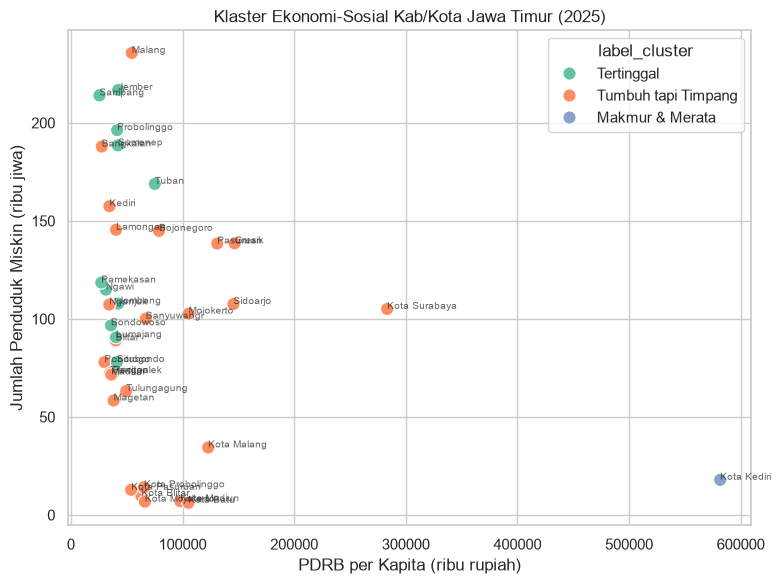

In [79]:
fitur = ["pdrb_per_kapita", "jumlah_penduduk_miskin", "tpt"]
df_cluster = df_latest.dropna(subset=fitur).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[fitur])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

# Lihat karakteristik rata-rata tiap cluster, untuk kasih nama yang bermakna
ringkasan_cluster = df_cluster.groupby("cluster")[fitur].mean().sort_values("pdrb_per_kapita", ascending=False)
display(ringkasan_cluster)

# --- Beri nama cluster secara manual berdasarkan hasil ringkasan_cluster di atas ---
# Sesuaikan urutan label ini setelah lihat tabel ringkasan_cluster (cluster mana yang PDRB tinggi/kemiskinan rendah, dst)
label_cluster = {
    ringkasan_cluster.index[0]: "Makmur & Merata",
    ringkasan_cluster.index[1]: "Tumbuh tapi Timpang",
    ringkasan_cluster.index[2]: "Tertinggal",
}
df_cluster["label_cluster"] = df_cluster["cluster"].map(label_cluster)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df_cluster, x="pdrb_per_kapita", y="jumlah_penduduk_miskin",
                 hue="label_cluster", s=90, ax=ax, palette="Set2")
for _, row in df_cluster.iterrows():
    ax.annotate(row["nama_wilayah"], (row["pdrb_per_kapita"], row["jumlah_penduduk_miskin"]),
                fontsize=7, alpha=0.7)
ax.set_title(f"Klaster Ekonomi-Sosial Kab/Kota Jawa Timur ({tahun_terbaru})")
ax.set_xlabel("PDRB per Kapita (ribu rupiah)")
ax.set_ylabel("Jumlah Penduduk Miskin (ribu jiwa)")
plt.tight_layout()
plt.savefig("output/klaster_kmeans.png", dpi=200)
plt.show()


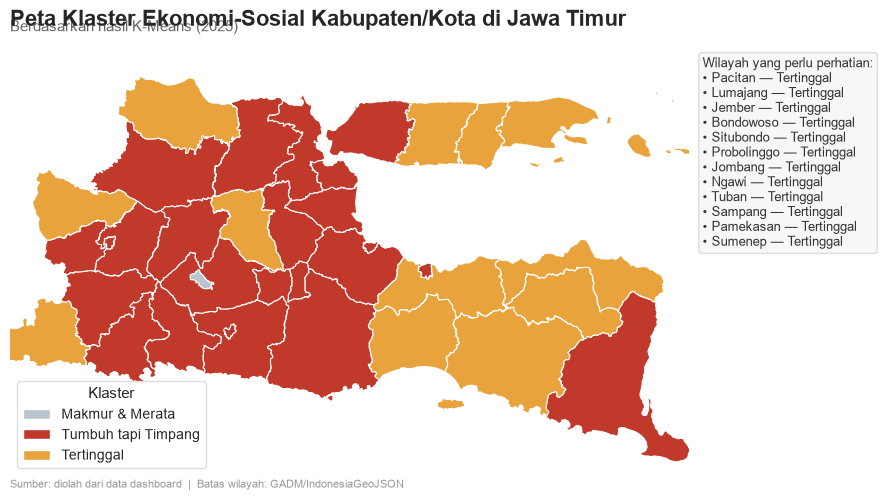

In [80]:
import urllib.request, json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Patch

# ---- Ambil geojson batas wilayah Jatim (sumber sama yang dipakai dashboard kamu) ----
url = 'https://raw.githubusercontent.com/TheMaggieSimpson/IndonesiaGeoJSON/master/kota-kabupaten.json'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req, timeout=20) as r:
    geo = json.loads(r.read().decode('utf-8'))
features = [f for f in geo['features'] if f['properties'].get('NAME_1') == 'Jawa Timur']

# ---- Palet: netral utk klaster mayoritas, aksen kuat HANYA utk klaster yang mau disorot ----
# Sesuaikan urutan nama label di sini persis dengan label_cluster yang sudah kamu buat
PALETTE = {
    "Makmur & Merata": "#B8C4CE",       # netral -- mayoritas / baseline
    "Tumbuh tapi Timpang": "#C0392B",   # aksen merah -- paling policy-relevant
    "Tertinggal": "#E8A33D",            # aksen kuning tanah -- perlu perhatian juga
}

df_cluster["kode_wilayah_str"] = df_cluster["kode_wilayah"].astype(str)
lookup = df_cluster.set_index("kode_wilayah_str")["label_cluster"].to_dict()

fig, ax = plt.subplots(figsize=(9, 9))

def add_geom(geom, color):
    if geom["type"] == "Polygon":
        rings = [geom["coordinates"][0]]
    elif geom["type"] == "MultiPolygon":
        rings = [poly[0] for poly in geom["coordinates"]]
    else:
        return
    for ring in rings:
        ax.add_patch(Polygon(ring, closed=True, facecolor=color,
                              edgecolor="white", linewidth=0.8, zorder=2))

for f in features:
    code = f["properties"].get("CC_2")
    label = lookup.get(code)
    add_geom(f["geometry"], PALETTE.get(label, "#DDDDDD"))

# Batas peta fix (Jatim + Madura) -- lebih stabil drpd auto-bbox yang bisa kena pulau kecil terpencil
ax.set_xlim(111.0, 114.6)
ax.set_ylim(-8.85, -6.65)
ax.set_aspect(1 / np.cos(np.radians(-7.7)))  # koreksi distorsi proyeksi sederhana
ax.axis("off")

ax.set_title("Peta Klaster Ekonomi-Sosial Kabupaten/Kota di Jawa Timur", fontsize=16,
              fontweight="bold", loc="left", pad=22)
ax.text(0.0, 1.06, f"Berdasarkan hasil K-Means ({tahun_terbaru})", transform=ax.transAxes,
        fontsize=11, color="#666666")

# Legend dengan background halus biar gak nyatu sama warna peta
handles = [Patch(facecolor=c, edgecolor="white", label=l) for l, c in PALETTE.items()]
ax.legend(handles=handles, loc="lower left", frameon=True, fontsize=10, title="Klaster",
          title_fontsize=11, facecolor="white", edgecolor="#DDDDDD", framealpha=0.95)

# Daftar wilayah yang disorot -- ganti leader-line yang berantakan dengan teks ringkas di sisi peta
# Kalau daftarnya panjang (>12), potong ke beberapa teratas saja atau pindah ke slide terpisah
sorot = df_cluster[df_cluster["label_cluster"] != "Makmur & Merata"].sort_values("label_cluster")
baris = [f"• {row.nama_wilayah} — {row.label_cluster}" for row in list(sorot.itertuples())[:12]]
ax.text(1.02, 1.0, "Wilayah yang perlu perhatian:\n" + "\n".join(baris), transform=ax.transAxes,
        fontsize=9, va="top", ha="left", color="#333333",
        bbox=dict(boxstyle="round", facecolor="#F7F7F7", edgecolor="#DDDDDD"))

ax.text(0.0, -0.03, "Sumber: diolah dari data dashboard  |  Batas wilayah: GADM/IndonesiaGeoJSON",
        transform=ax.transAxes, fontsize=8, color="#999999")

plt.tight_layout()
plt.savefig("output/peta_klaster_kmeans.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

**Catatan:** cek dulu isi `ringkasan_cluster` sebelum nentuin nama label — urutan cluster 0/1/2 dari K-Means itu random, jadi harus disesuaikan manual mana yang PDRB-nya tinggi/rendah, kemiskinannya tinggi/rendah.


## 6. Ekspor Hasil untuk Desain Infografis

Simpan semua angka penting (index ketimpangan per tahun, korelasi, hasil klaster) ke CSV supaya tinggal dipakai pas nyusun infografis di Canva/Figma — gak perlu buka notebook lagi pas desain.


In [81]:
# Data per kab/kota (tahun terbaru) lengkap dengan cluster
df_cluster.to_csv("output/hasil_klaster_kabkota.csv", index=False)

# Tren index ketimpangan per tahun
df_index.to_csv("output/tren_index_ketimpangan.csv", index=False)

# Ringkasan angka-angka headline buat infografis
ringkasan = pd.DataFrame({
    "metrik": [
        f"Williamson Index {tahun_terbaru}",
        f"CV {tahun_terbaru}",
        "Korelasi PDRB vs Kemiskinan (r)",
        "P-value korelasi",
        "Jumlah klaster",
    ],
    "nilai": [
        df_index.loc[df_index['tahun'] == tahun_terbaru, 'williamson_index'].values[0],
        df_index.loc[df_index['tahun'] == tahun_terbaru, 'cv'].values[0],
        r,
        p_value,
        df_cluster["cluster"].nunique(),
    ]
})
ringkasan.to_csv("output/ringkasan_headline.csv", index=False)
display(ringkasan)

print("\nSemua file hasil sudah tersimpan di folder output/")


,metrik,nilai
0,Williamson Index 2025,0.98
1,CV 2025,1.21
2,Korelasi PDRB vs Kemiskinan (r),<http.client.HTTPResponse object at 0x00000170...
3,P-value korelasi,0.12
4,Jumlah klaster,3



Semua file hasil sudah tersimpan di folder output/
